# HWRS640 – Assignment 4: Exploratory Data Analysis

This notebook explores the `minicamels` dataset and builds intuition for the streamflow prediction problem.

**Contents**
1. Dataset overview (structure, variables, time span)
2. Train / validation / test split justification
3. Supervised learning problem definition
4. Exploratory plots
5. Preprocessing notes

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from minicamels import MiniCamels
from data import load_all_basins, split_basin_df, DYNAMIC_VARS, TARGET_VAR, SPLIT_DATES

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Dataset structure

In [2]:
mc = MiniCamels()
basins_df = mc.basins()
attrs_df  = mc.attributes()

basin_ids = basins_df['basin_id'].tolist()
print(f'Number of basins          : {len(basin_ids)}')
print(f'Time span                 : 1980-10-01 – 2010-09-30 (WY1981–WY2010, 30 water years)')
print(f'Dynamic input variables   : {DYNAMIC_VARS}')
print(f'Target variable           : {TARGET_VAR} (mm/day)')
print(f'Static attributes ({attrs_df.shape[1]})    : {attrs_df.columns.tolist()}')

Number of basins          : 50
Time span                 : 1980-10-01 – 2010-09-30 (WY1981–WY2010, 30 water years)
Dynamic input variables   : ['prcp', 'tmax', 'tmin', 'srad', 'vp']
Target variable           : qobs (mm/day)
Static attributes (16)    : ['lat', 'lon', 'elev_mean', 'slope_mean', 'area_km2', 'mean_prcp', 'mean_pet', 'aridity', 'frac_snow', 'q_mean', 'runoff_ratio', 'hfd_mean', 'baseflow_index', 'soil_depth_pelletier', 'frac_forest', 'lai_max']


In [3]:
basins_df.head(10)

,basin_id,basin_name
0,01013500,"Fish River near Fort Kent, Maine"
1,01580000,"DEER CREEK AT ROCKS, MD"
2,02016000,"COWPASTURE RIVER NEAR CLIFTON FORGE, VA"
3,02064000,"FALLING RIVER NEAR NARUNA, VA"
4,02221525,"MURDER CREEK BELOW EATONTON, GA"
5,02297310,HORSE CREEK NEAR ARCADIA FL
6,02298123,PRAIRIE CREEK NEAR FORT OGDEN FL
7,02371500,CONECUH RIVER AT BRANTLEY AL
8,02415000,HILLABEE CREEK NEAR HACKNEYVILLE AL
9,03504000,"NANTAHALA RIVER NEAR RAINBOW SPRINGS, NC"


In [4]:
attrs_df.describe()

,lat,lon,elev_mean,slope_mean,area_km2,mean_prcp,mean_pet,aridity,frac_snow,q_mean,runoff_ratio,hfd_mean,baseflow_index,soil_depth_pelletier,frac_forest,lai_max
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,40.772657,-105.074655,814.518400,71.833094,921.472800,3.467133,2.706403,1.055435,0.224202,1.862768,0.449709,187.588533,0.514805,8.967541,0.693810,2.979213
std,6.285234,17.548389,647.197692,62.647362,1193.412567,1.619971,0.487568,0.879524,0.242234,1.931271,0.262674,41.582625,0.170884,15.665621,0.370976,1.344509
min,27.052000,-124.315750,21.750000,0.822210,50.200000,0.644565,1.899096,0.232886,0.000000,0.042584,0.037512,117.100000,0.042775,0.472727,0.000100,0.405882
25%,36.892975,-121.738317,276.225000,9.779070,235.877500,2.666261,2.345849,0.666773,0.035670,0.847302,0.284905,148.800000,0.432686,0.897477,0.428750,1.826673
50%,41.613775,-115.026390,650.785000,91.508025,449.185000,3.201875,2.651823,0.868821,0.112807,1.319591,0.390628,189.100000,0.535396,1.144144,0.888500,3.136845
75%,46.136040,-86.365140,1367.555000,112.410938,1105.052500,3.937903,3.059037,0.968941,0.413985,2.290838,0.609971,218.850000,0.629838,6.817492,0.978150,4.212753
max,48.822920,-68.582640,2256.430000,245.561310,5318.590000,8.154612,4.042907,5.207913,0.777311,9.688438,1.188093,287.750000,0.886909,49.874488,1.000000,5.088656


## 2. Train / val / test split

We use a **temporal split across all 50 basins**:

| Split | Water years    | Dates                        | Duration |
|-------|---------------|------------------------------|----------|
| Train | WY1981–WY2003 | 1980-10-01 – 2003-09-30      | 23 yr    |
| Val   | WY2004–WY2006 | 2003-10-01 – 2006-09-30      |  3 yr    |
| Test  | WY2007–WY2010 | 2006-10-01 – 2010-09-30      |  4 yr    |

**Justification.** A temporal hold-out is natural for rainfall-runoff modelling: we want to verify that the model generalises to future (unseen) meteorological conditions, not just to unseen basins.  All 50 basins contribute to each split, giving the model a broad representation of basin diversity.  Using the most recent years as the test set avoids any form of temporal look-ahead leakage, since normalisation statistics (mean, std) are computed solely on the training window and applied to val/test.

In [5]:
for split, (s, e) in SPLIT_DATES.items():
    days = (pd.Timestamp(e) - pd.Timestamp(s)).days + 1
    print(f'  {split:5s}  {s} – {e}  ({days:,} days / basin, 50 basins)')

  train  1980-10-01 – 2003-09-30  (8,400 days / basin, 50 basins)
  val    2003-10-01 – 2006-09-30  (1,096 days / basin, 50 basins)
  test   2006-10-01 – 2010-09-30  (1,461 days / basin, 50 basins)


## 3. Supervised learning problem definition

- **Sequence length** : 365 days (configurable via CLI; captures full annual cycle).
- **Model input**     : `(seq_len, num_dynamic + num_static)` = `(365, 21)` — five daily Daymet forcings plus 16 static basin attributes tiled along the time dimension.
- **Target**          : `qobs` at the **last timestep** of the window (one-step-ahead prediction).
- **Sliding window**  : for each basin-split combination we slide the window forward by one day at a time, generating one supervised sample per day.

The one-step-ahead formulation is the standard in hydrology sequence modelling (e.g. Kratzert et al. 2018); it is simple, allows daily evaluation, and avoids the multi-step error accumulation problem.

## 4. Load basin data

In [6]:
print('Loading all basin data (remote fetch – may take a minute)...')
basin_dfs, _ = load_all_basins(mc)
print('Done.')

# Quick look at one basin
example_id = basin_ids[0]
basin_dfs[example_id].head()

Loading all basin data (remote fetch – may take a minute)...
Done.


,prcp,tmax,tmin,srad,vp,qobs
time,,,,,,
1980-10-01,3.10,10.05,2.11,192.610001,711.330017,0.552805
1980-10-02,4.24,15.82,5.24,206.309998,898.609985,0.562580
1980-10-03,8.02,15.86,7.81,165.350006,1064.859985,0.560408
1980-10-04,15.27,11.10,3.66,159.779999,794.179993,0.673358
1980-10-05,8.48,7.58,2.02,133.830002,705.500000,0.824321


## 5. Exploratory plots

### 5.1 Streamflow time series for five basins

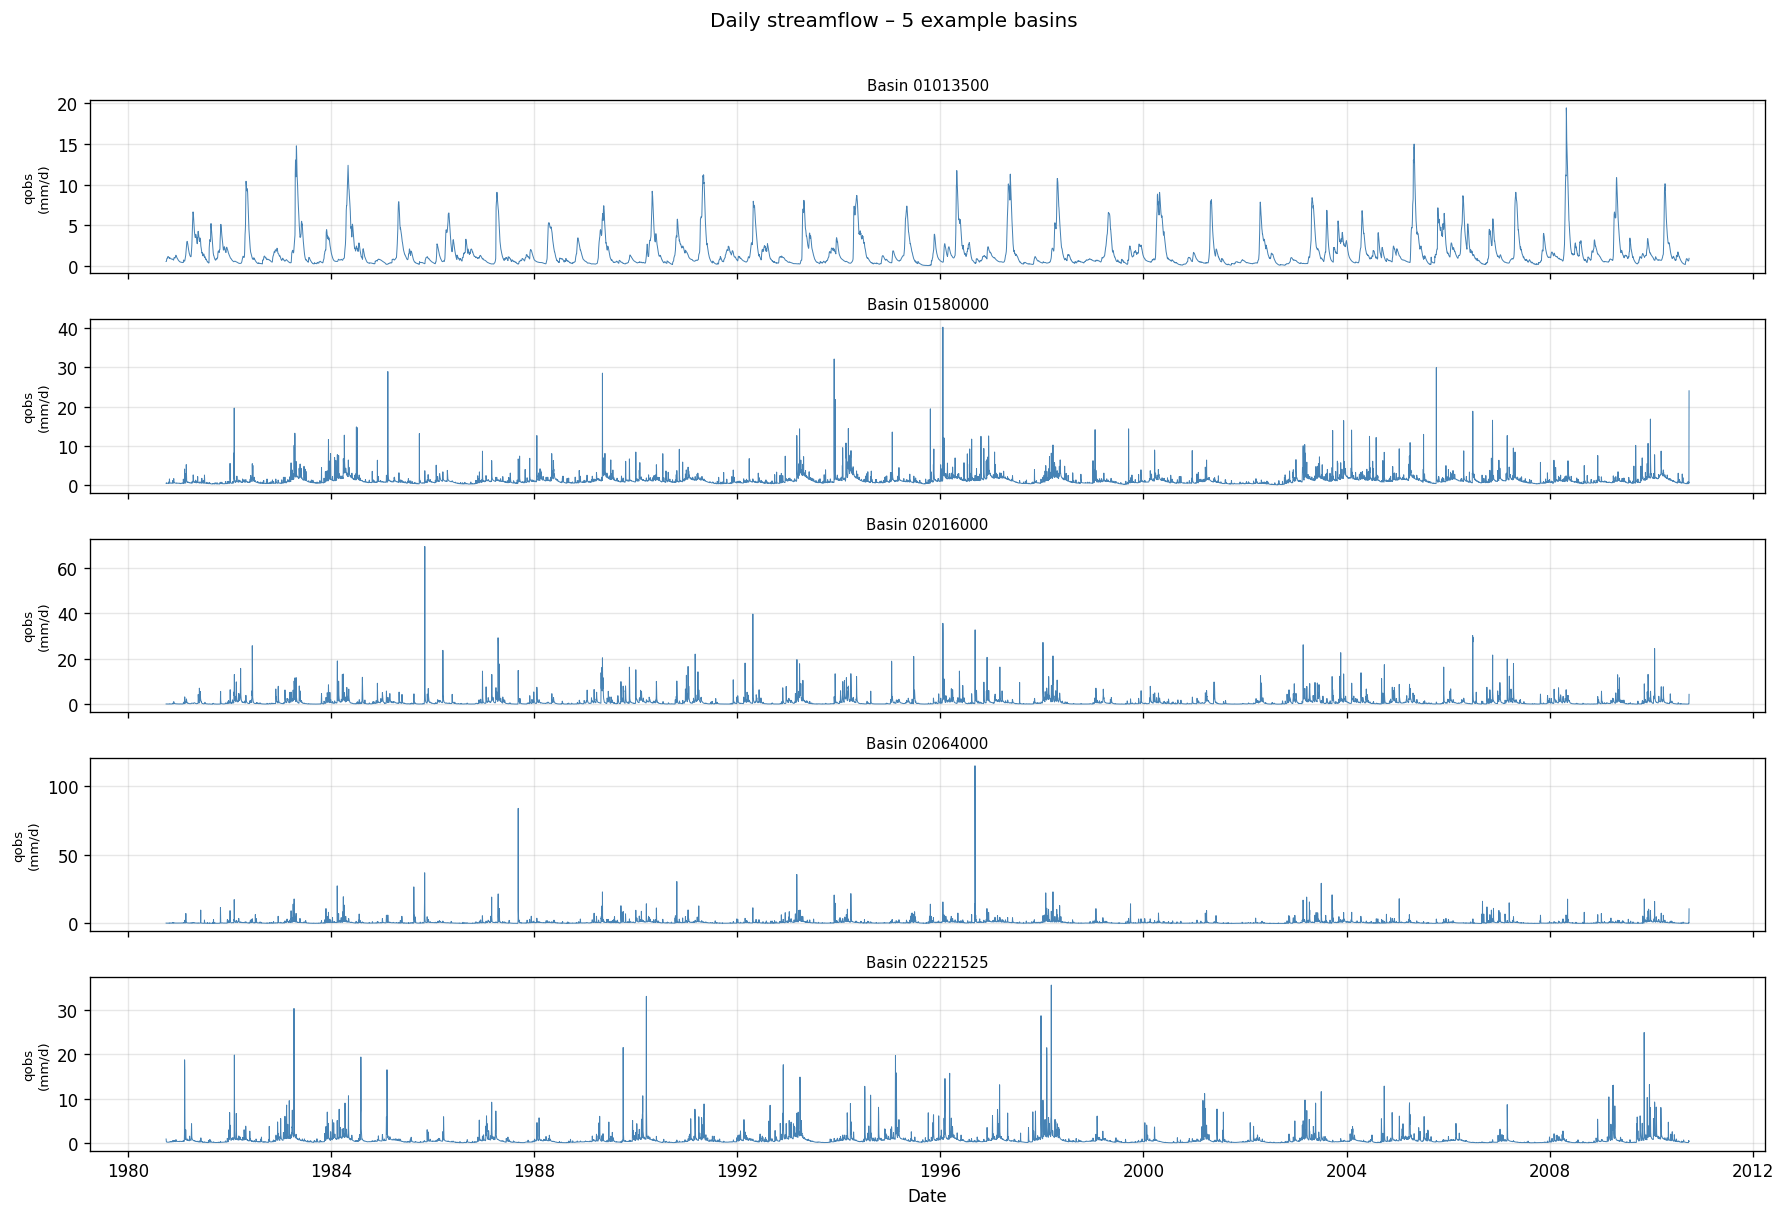

In [7]:
sample_ids = basin_ids[:5]
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(15, 10), sharex=True)

for ax, bid in zip(axes, sample_ids):
    df = basin_dfs[bid]
    ax.plot(df.index, df['qobs'], linewidth=0.6, color='steelblue')
    ax.set_ylabel('qobs\n(mm/d)', fontsize=8)
    ax.set_title(f'Basin {bid}', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Daily streamflow – 5 example basins', y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Precipitation and streamflow for one basin

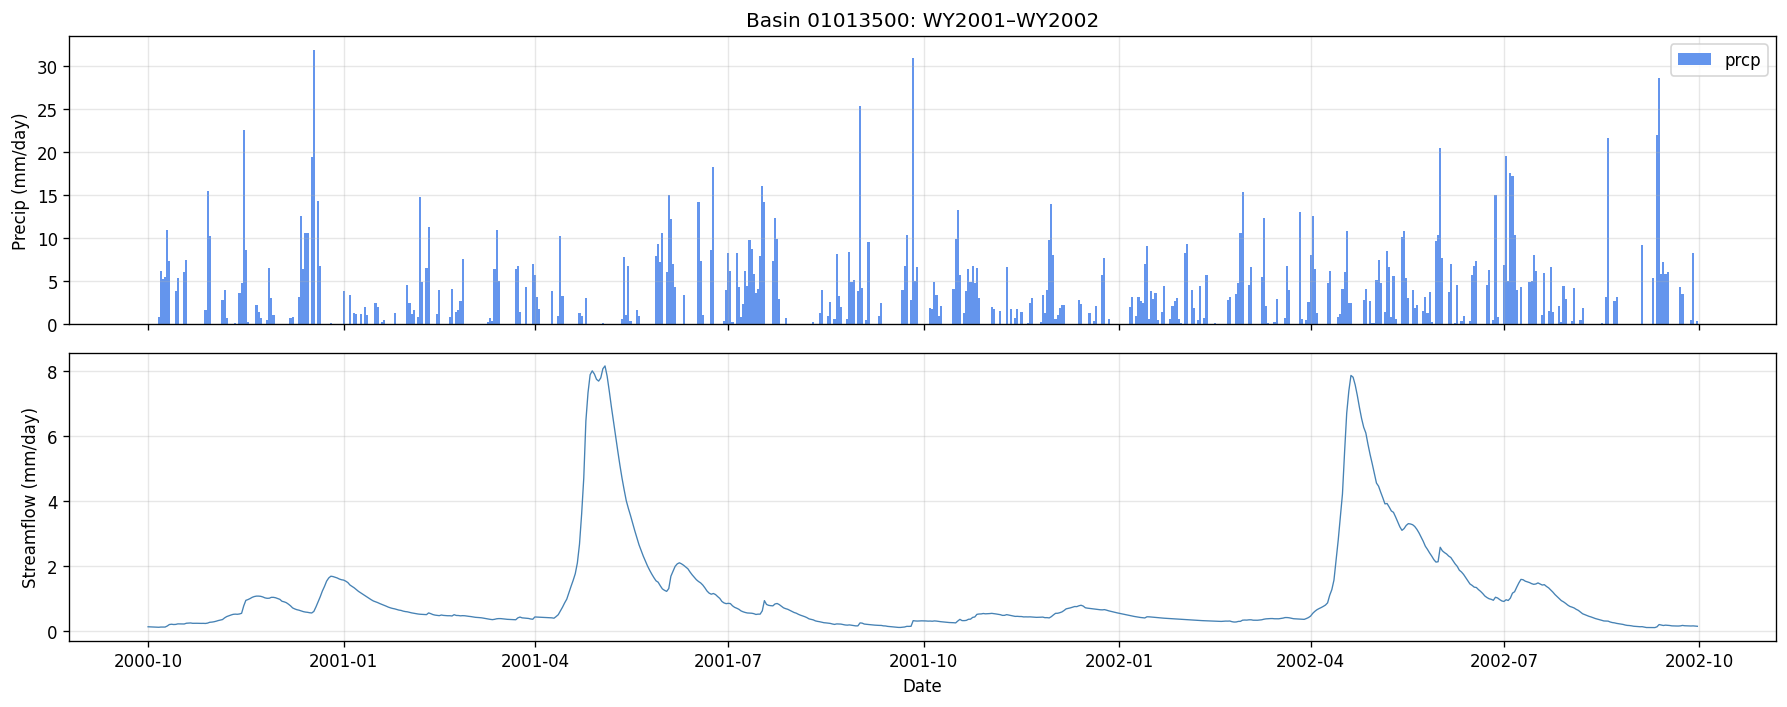

In [8]:
bid = basin_ids[0]
sub = basin_dfs[bid].loc['2000-10-01':'2002-09-30']

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axes[0].bar(sub.index, sub['prcp'], color='cornflowerblue', width=1, label='prcp')
axes[0].set_ylabel('Precip (mm/day)')
axes[0].set_title(f'Basin {bid}: WY2001–WY2002')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sub.index, sub['qobs'], color='steelblue', linewidth=0.8)
axes[1].set_ylabel('Streamflow (mm/day)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Distribution of qobs (all basins)

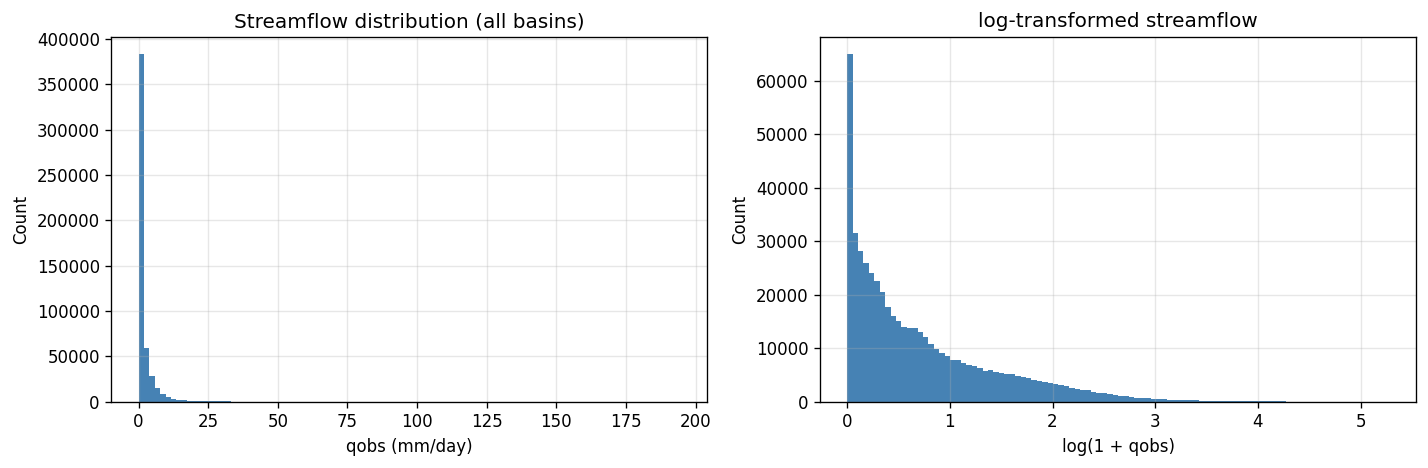

qobs stats — mean: 1.95, median: 0.63, p99: 17.89, max: 194.51


In [9]:
all_q = np.concatenate([df['qobs'].dropna().values for df in basin_dfs.values()])
all_q = all_q[all_q > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_q, bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('qobs (mm/day)')
axes[0].set_ylabel('Count')
axes[0].set_title('Streamflow distribution (all basins)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.log1p(all_q), bins=100, color='steelblue', edgecolor='none')
axes[1].set_xlabel('log(1 + qobs)')
axes[1].set_ylabel('Count')
axes[1].set_title('log-transformed streamflow')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'qobs stats — mean: {all_q.mean():.2f}, median: {np.median(all_q):.2f}, '
      f'p99: {np.percentile(all_q, 99):.2f}, max: {all_q.max():.2f}')

### 5.4 Static attribute scatter: aridity vs runoff ratio

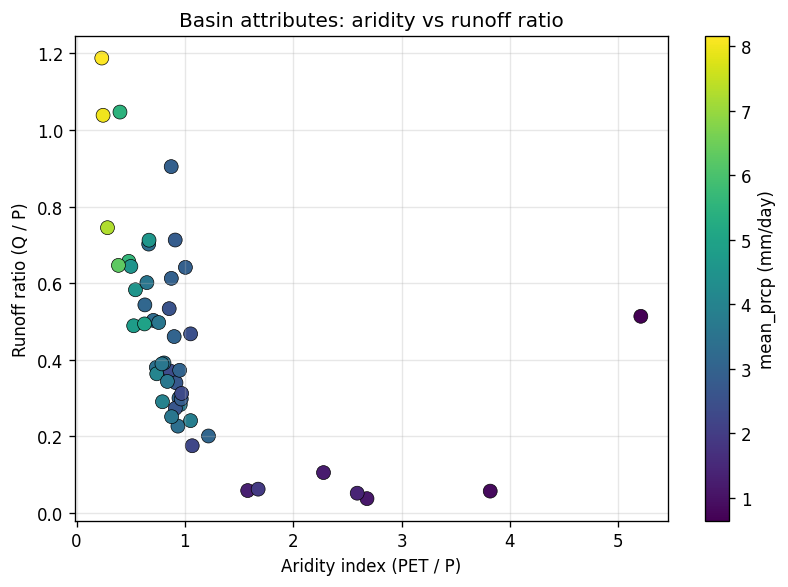

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    attrs_df['aridity'], attrs_df['runoff_ratio'],
    c=attrs_df['mean_prcp'], cmap='viridis', s=70, edgecolors='k', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='mean_prcp (mm/day)')
ax.set_xlabel('Aridity index (PET / P)')
ax.set_ylabel('Runoff ratio (Q / P)')
ax.set_title('Basin attributes: aridity vs runoff ratio')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Seasonal streamflow pattern (all basins, median)

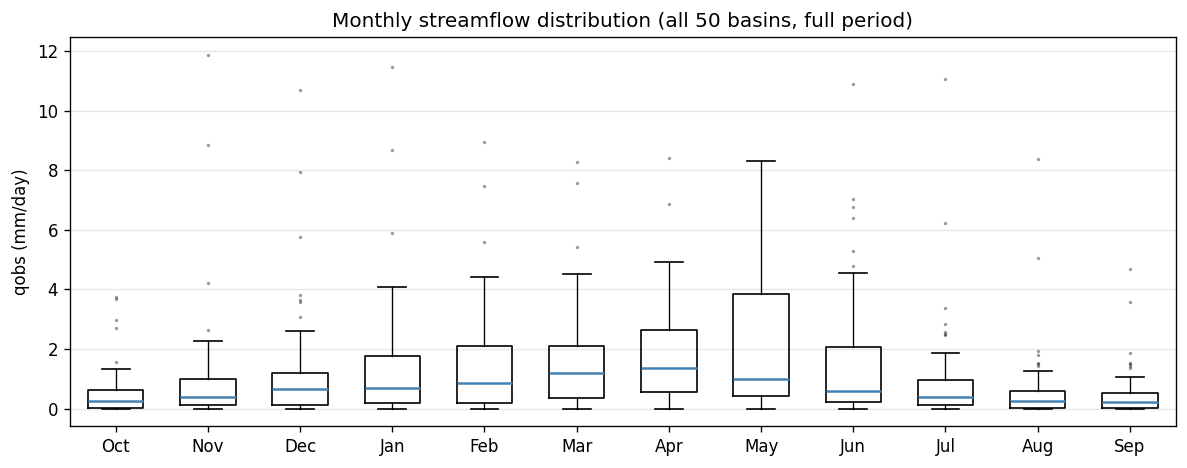

In [11]:
monthly_medians = []
for df in basin_dfs.values():
    mm = df['qobs'].groupby(df.index.month).median()
    monthly_medians.append(mm)

seasonal = pd.concat(monthly_medians, axis=1).T
months = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
month_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # water year order

fig, ax = plt.subplots(figsize=(10, 4))
for i, col in enumerate(month_order):
    vals = seasonal[col].values
    ax.boxplot(vals, positions=[i+1], widths=0.6,
               medianprops=dict(color='steelblue', linewidth=1.5),
               whiskerprops=dict(linewidth=0.8),
               flierprops=dict(marker='.', markersize=2, alpha=0.4))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_ylabel('qobs (mm/day)')
ax.set_title('Monthly streamflow distribution (all 50 basins, full period)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Preprocessing notes

### Missing values
The minicamels dataset is largely complete; any `NaN` rows in `qobs` are excluded when constructing sliding windows (`dropna(subset=['qobs'])` in `data.py`).

### Normalisation
- **Dynamic forcings** (`prcp`, `tmax`, `tmin`, `srad`, `vp`): z-score normalised per feature using the training split mean and standard deviation.
- **Streamflow** (`qobs`): z-score normalised using the training split statistics. The model operates in normalised space; predictions are inverse-transformed before metric computation.
- **Static attributes**: z-score normalised using per-attribute statistics computed across all 50 basins in the training split.

All normalisation statistics are derived from the **training split only** to avoid leakage into validation/test.

### Static attribute integration
Static attributes are **tiled along the time axis** so each input timestep vector has shape `(5 dynamic + 16 static) = 21`.  This is the simplest approach and works well with both LSTM and Transformer architectures without adding extra fusion modules.

### Sequence window construction
A sliding window of length `seq_len` (default 365 days) is passed over each basin time series.  The target is `qobs` at the last timestep (`t`), and the input spans timesteps `t − seq_len + 1` through `t`.  Consecutive windows overlap by `seq_len − 1` days, yielding dense supervision signal.

In [12]:
# Spot-check: sample counts per split
from data import StreamflowDataset, fit_normalizers

dyn_norm, tgt_norm, static_norm = fit_normalizers(basin_dfs, attrs_df)

common = dict(basin_dfs=basin_dfs, attrs_df=attrs_df, seq_len=365,
              dyn_norm=dyn_norm, tgt_norm=tgt_norm, static_norm=static_norm)

for split in ['train', 'val', 'test']:
    ds = StreamflowDataset(split=split, **common)
    print(f'{split:5s}: {len(ds):>8,} samples')

train:  390,754 samples
val  :   36,600 samples
test :   54,850 samples
